# Rating model — does the persona improve predictions?

**Goal.** Predict the rating (1–5) a user would give a movie **nobody has rated yet** (validation / test movies from `07`), from its TMDB metadata, the user's history on training movies and the user's persona (`08`). A movie is added to the user's recommended list when the predicted rating passes a threshold chosen from section 7.

Research questions answered here:
- **RQ4:** how much does the error drop from simple averages to a personalized model, and does the persona add to it? (sections 4–5)
- **RQ2:** does the polarization taste (`rating_std`) used in the clustering improve predictions? (section 6)
- **RQ3:** which features matter most, and does it differ between personas, e.g. the director's track record? (section 8)

The test movies are used once, in section 5; all choices are made on validation movies.

## 1. Load

Outputs of `06`–`08`. Only users with a persona (≥ 20 training ratings) are modelled.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

PROCESSED = Path("../data/processed")
RANDOM_STATE = 42
SHRINK = 3

movies = (
    pd.read_csv(PROCESSED / "movies_features.csv", usecols=lambda c: c != "cast_top5")
    .merge(pd.read_csv(PROCESSED / "movie_split.csv"), on="netflix_movie_id")
    .merge(pd.read_csv(PROCESSED / "track_records.csv"), on="netflix_movie_id")
    .set_index("netflix_movie_id")
)
user_stats = pd.read_csv(PROCESSED / "user_stats_train.csv").set_index("rater_id")
profiles = pd.read_csv(PROCESSED / "user_profiles.csv").set_index("rater_id").add_prefix("taste_")
personas = pd.read_csv(PROCESSED / "user_personas.csv").set_index("rater_id")
persona_genre = pd.read_csv(PROCESSED / "persona_genre_scores.csv").set_index("persona")
K = len(persona_genre)

GENRE_COLS = [c for c in movies.columns if c.startswith("genre_")]
COMPANY_COLS = [c for c in movies.columns if c.startswith("company_")]
print(f"movies: {movies['split'].value_counts().to_dict()} | users with persona: {len(personas):,} | personas: {K}")

movies: {'train': 919, 'test': 198, 'val': 197} | users with persona: 332,265 | personas: 5


## 2. Ratings: sample of users + persona × movie scores

Ratings are read once, in chunks:
- all ratings (training, validation and test movies) of a **random sample of users** become the modelling rows. 8,000 users give ~0.8M training rows, plenty for ~100 features; the limit is memory (the model converts the training matrix to 64-bit floats, ~0.6 GB at this size). Raise `N_USERS` on a machine with more RAM;
- over **all** users with a persona, the training ratings are summed per persona and movie: the average `rating − user_mean` each persona gives each training movie. It feeds `persona_director_score` (section 3).

Lookup arrays indexed by user / movie id keep the pass fast and light.

In [2]:
N_USERS = 8_000
SPLITS = ["train", "val", "test"]

rng = np.random.default_rng(RANDOM_STATE)
sample_users = rng.choice(personas.index.to_numpy(), size=N_USERS, replace=False)

USER_LUT = int(user_stats.index.max()) + 1
MOVIE_LUT = int(movies.index.max()) + 1
is_sample = np.zeros(USER_LUT, dtype=bool)
is_sample[sample_users] = True
user_mean_lut = np.zeros(USER_LUT)
user_mean_lut[user_stats.index] = user_stats["user_mean"]
persona_lut = np.full(USER_LUT, -1, dtype="int8")
persona_lut[personas.index] = personas["persona_id"]
split_lut = np.full(MOVIE_LUT, -1, dtype="int8")
for code_, name in enumerate(SPLITS):
    split_lut[movies.index[movies["split"] == name]] = code_

rows = []
pm_sum = np.zeros(K * MOVIE_LUT)
pm_n = np.zeros(K * MOVIE_LUT)
chunks = pd.read_csv(
    PROCESSED / "ratings.csv",
    usecols=["netflix_movie_id", "rater_id", "rating"],
    dtype={"netflix_movie_id": "int32", "rater_id": "int32", "rating": "int8"},
    chunksize=5_000_000,
)
for chunk in chunks:
    chunk = chunk[(chunk["rater_id"] < USER_LUT) & (chunk["netflix_movie_id"] < MOVIE_LUT)]
    rid, mid = chunk["rater_id"].to_numpy(), chunk["netflix_movie_id"].to_numpy()
    split = split_lut[mid]
    rows.append(chunk[is_sample[rid] & (split >= 0)].assign(split=split[is_sample[rid] & (split >= 0)]))

    in_train = (split == 0) & (persona_lut[rid] >= 0)
    flat = persona_lut[rid[in_train]].astype(int) * MOVIE_LUT + mid[in_train]
    dev = chunk["rating"].to_numpy()[in_train] - user_mean_lut[rid[in_train]]
    pm_sum += np.bincount(flat, weights=dev, minlength=K * MOVIE_LUT)
    pm_n += np.bincount(flat, minlength=K * MOVIE_LUT)

data = pd.concat(rows, ignore_index=True)
with np.errstate(invalid="ignore"):
    persona_movie_dev = (pm_sum / pm_n).reshape(K, MOVIE_LUT)

print(f"sample users: {N_USERS:,} | rows per split:", data["split"].map(dict(enumerate(SPLITS))).value_counts().to_dict())

sample users: 8,000 | rows per split: {'train': 816917, 'val': 185120, 'test': 175793}


## 3. Features

| group | features | source |
|---|---|---|
| **A. Movie content** | `runtime`, `movie_age_log`, `log_roi`, 18 `genre_*`, 16 `company_*`, `us_only` / `us_coproduction` / `non_us`, `lang_en`, `is_multilingual`, `director_track_record`, `cast_track_record` | `06`, `07` |
| **B. User behaviour** | `user_mean`, `user_std`, `user_n_log`, `user_pct_ge4` | `07` |
| **C. User taste profile** | the 27 `taste_*` columns (genre and production taste, polarization taste) | `08` |
| **E1. User × movie match** | `user_genre_match` (the user's taste for the movie's genres, averaged over them); `match_*` = user's taste for a production feature × the movie's standardized value of it (e.g. a user who likes long films × a long film) | computed here |
| **D. Persona** | persona one-hot `persona_0…`, distances to the persona centres `dist_0…` | `08` |
| **E2. Persona × movie** | `persona_genre_score` (how far above / below their own average the user's persona rates the movie's genres), `persona_director_score` (how the persona rated the director's *other* training films, shrunk toward 0 with m = 3) | `08`, section 2 |

**Leakage.** Every statistic is computed from training movies. For a **training row**, the user's statistics (group B) would contain the very rating being predicted, while for validation / test rows they never do; the row's own rating is therefore removed from them (leave-one-out), and `persona_director_score` uses only the director's *other* films. The taste profile (C) still contains the row's own rating with weight ~1/100 (users have ≥ 20, median ~70 training ratings); this can make training rows look slightly easier than new movies, but all model comparisons are on validation / test movies, where no feature contains the answer.

In [3]:
MOVIE_NUMERIC = ["runtime", "movie_age_log", "log_roi"]
MOVIE_OTHER = COMPANY_COLS + ["us_only", "us_coproduction", "non_us", "lang_en", "is_multilingual"]
TRACK_COLS = ["director_track_record", "cast_track_record"]
MOVIE_COLS = MOVIE_NUMERIC + GENRE_COLS + MOVIE_OTHER + TRACK_COLS
USER_COLS = ["user_mean", "user_std", "user_n_log", "user_pct_ge4"]
TASTE_COLS = list(profiles.columns)
MATCH_BASE = ["runtime", "movie_age_log", "log_roi", "director_track_record", "cast_track_record", "lang_en", "non_us"]
MATCH_COLS = ["user_genre_match"] + [f"match_{c}" for c in MATCH_BASE]
PERSONA_COLS = [f"persona_{k}" for k in range(K)] + [f"dist_{k}" for k in range(K)]
PERSONA_MATCH_COLS = ["persona_genre_score", "persona_director_score"]

train_movie_ids = movies.index[movies["split"] == "train"]
movie_z = (movies[MATCH_BASE] - movies.loc[train_movie_ids, MATCH_BASE].mean()) / movies.loc[train_movie_ids, MATCH_BASE].std()


def director_score_table():
    """(movie x persona): shrunk mean of the persona's deviation on the director's other training films."""
    table = np.zeros((len(movies), K))
    for p in range(K):
        v = pd.Series(persona_movie_dev[p, movies.index], index=movies.index)
        v[movies["split"] != "train"] = np.nan  # only training films count
        totals = v.groupby(movies["director"]).agg(["sum", "count"])
        j = totals.reindex(movies["director"]).fillna(0).to_numpy()
        other_sum = j[:, 0] - v.fillna(0).to_numpy()
        other_n = j[:, 1] - v.notna().to_numpy()
        table[:, p] = other_sum / (other_n + SHRINK)
    return pd.DataFrame(table, index=movies.index)


director_scores = director_score_table()


def build_features(df):
    movie = movies.reindex(df["netflix_movie_id"])
    X = pd.DataFrame(movie[MOVIE_COLS].to_numpy(dtype="float32"), columns=MOVIE_COLS)

    # B. user behaviour, leave-one-out on training rows
    us = user_stats.reindex(df["rater_id"])
    n, mean, std, pct = (us[c].to_numpy() for c in ["user_n", "user_mean", "user_std", "user_pct_ge4"])
    own = (df["split"].to_numpy() == 0).astype(float)
    r = df["rating"].to_numpy(dtype=float)
    n_loo = n - own
    mean_loo = (n * mean - own * r) / n_loo
    sumsq_loo = (n - 1) * std**2 + n * mean**2 - own * r**2
    X["user_mean"] = mean_loo
    X["user_std"] = np.sqrt(np.maximum((sumsq_loo - n_loo * mean_loo**2) / (n_loo - 1), 0))
    X["user_n_log"] = np.log(n_loo)
    X["user_pct_ge4"] = (n * pct - own * (r >= 4)) / n_loo

    # C. taste profile
    taste = profiles.reindex(df["rater_id"])
    X[TASTE_COLS] = taste.to_numpy(dtype="float32")

    # E1. user x movie match
    genres = movie[GENRE_COLS].to_numpy()
    n_genres = np.maximum(genres.sum(axis=1), 1)
    X["user_genre_match"] = (genres * taste[[f"taste_{g}" for g in GENRE_COLS]].to_numpy()).sum(axis=1) / n_genres
    z = movie_z.reindex(df["netflix_movie_id"]).to_numpy()
    for j, c in enumerate(MATCH_BASE):
        X[f"match_{c}"] = taste[f"taste_{c}"].to_numpy() * z[:, j]

    # D. persona
    pers = personas.reindex(df["rater_id"])
    persona = pers["persona_id"].to_numpy()
    for k in range(K):
        X[f"persona_{k}"] = (persona == k).astype("float32")
        X[f"dist_{k}"] = pers[f"dist_{k}"].to_numpy()
    X["persona_no_std"] = pers["persona_id_no_std"].to_numpy()  # RQ2 only, not a model feature

    # E2. persona x movie
    pg = persona_genre[[g.removeprefix("genre_") for g in GENRE_COLS]].to_numpy()[persona]
    X["persona_genre_score"] = (genres * pg).sum(axis=1) / n_genres
    X["persona_director_score"] = director_scores.reindex(df["netflix_movie_id"]).to_numpy()[np.arange(len(df)), persona]
    return X.astype("float32")


parts = {name: data[data["split"] == code_].reset_index(drop=True) for code_, name in enumerate(SPLITS)}
X = {name: build_features(part) for name, part in parts.items()}
y = {name: part["rating"].to_numpy(dtype="float32") for name, part in parts.items()}
del data

print({name: X[name].shape for name in SPLITS})
X["val"][MOVIE_NUMERIC + TRACK_COLS + USER_COLS + MATCH_COLS + PERSONA_MATCH_COLS].describe().T.round(3)

{'train': (816917, 96), 'val': (185120, 96), 'test': (175793, 96)}


,count,mean,std,min,25%,50%,75%,max
runtime,185120.0,121.830,20.954,80.000,107.000,117.000,135.000,197.000
movie_age_log,185120.0,1.881,0.801,0.000,1.386,1.792,2.398,4.500
log_roi,185120.0,1.362,1.118,-4.443,0.784,1.310,1.777,5.573
director_track_record,185120.0,3.462,0.097,3.107,3.421,3.441,3.531,3.711
cast_track_record,185120.0,3.447,0.049,3.333,3.418,3.441,3.476,3.583
user_mean,185120.0,3.593,0.418,1.121,3.319,3.584,3.858,4.989
user_std,185120.0,0.961,0.194,0.147,0.827,0.948,1.083,1.893
user_n_log,185120.0,4.924,0.787,2.996,4.407,5.024,5.517,6.560
user_pct_ge4,185120.0,0.561,0.176,0.000,0.440,0.560,0.685,1.000
user_genre_match,185120.0,0.010,0.059,-0.368,-0.025,0.007,0.040,0.429


## 4. Model ladder (RQ4)

Each step adds information; all are scored on the same validation rows.

| model | uses | question |
|---|---|---|
| **B0** global mean | nothing | the floor |
| **B1** user mean | the user's average rating | how much does knowing the user's generosity give? (proposal: "global / user averages" baseline; a new movie has no average of its own) |
| **M1** content + user | A + B | a non-personalized model: how good is the movie for an average user, shifted by the user's generosity |
| **M2** + taste | A + B + C + E1 | personalization from the user's own taste profile, without personas |
| **M3** + persona | all groups | does the persona add anything on top? |

Models M1–M3 are gradient-boosted trees (`HistGradientBoostingRegressor`), which handle mixed feature types and interactions without scaling. Its size (`max_leaf_nodes`) is chosen on validation for M3 and reused for all models; a Ridge regression on the M3 features is a linear reference.

**Metric:** RMSE (root mean squared error, in stars) — the typical size of a prediction error, with large errors weighted more; MAE (mean absolute error) as a second view.

In [4]:
FEATURES = {
    "M1 content + user": MOVIE_COLS + USER_COLS,
    "M2 + taste": MOVIE_COLS + USER_COLS + TASTE_COLS + MATCH_COLS,
    "M3 + persona": MOVIE_COLS + USER_COLS + TASTE_COLS + MATCH_COLS + PERSONA_COLS + PERSONA_MATCH_COLS,
}


def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def hgb(**params):
    return HistGradientBoostingRegressor(
        learning_rate=0.1, max_iter=300, early_stopping=False, random_state=RANDOM_STATE, **params
    )


def fit(model, cols, X_train=None):
    # pass one float64 array: sklearn would otherwise keep both the float32 selection and its own float64 copy
    X_train = X["train"][cols] if X_train is None else X_train
    return model.fit(X_train.to_numpy(dtype=np.float64), y["train"])


def predict(model, X_part):
    return np.clip(model.predict(X_part.to_numpy(dtype=np.float64)), 1, 5)


tuning, tuned_models = {}, {}
for leaves in [31, 127]:
    model = fit(hgb(max_leaf_nodes=leaves, min_samples_leaf=100), FEATURES["M3 + persona"])
    tuned_models[leaves] = model
    tuning[leaves] = rmse(y["val"], predict(model, X["val"][FEATURES["M3 + persona"]]))
BEST_LEAVES = min(tuning, key=tuning.get)
print("validation RMSE by max_leaf_nodes:", {k: round(v, 4) for k, v in tuning.items()}, "-> chosen", BEST_LEAVES)

validation RMSE by max_leaf_nodes: {31: 0.9383, 127: 0.9432} -> chosen 31


In [5]:
global_mean = float(y["train"].mean())
pred = {name: {} for name in SPLITS[1:]}
for split in ["val", "test"]:
    pred[split]["B0 global mean"] = np.full(len(y[split]), global_mean)
    pred[split]["B1 user mean"] = X[split]["user_mean"].to_numpy()

models = {}
for name, cols in FEATURES.items():
    if name == "M3 + persona":
        models[name] = tuned_models[BEST_LEAVES]  # already fitted while tuning
    else:
        models[name] = fit(hgb(max_leaf_nodes=BEST_LEAVES, min_samples_leaf=100), cols)
    for split in ["val", "test"]:
        pred[split][name] = predict(models[name], X[split][cols])

# linear reference on a subsample: scaling + solving on all training rows would need several GB
ridge_idx = rng.choice(len(y["train"]), size=min(500_000, len(y["train"])), replace=False)
ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(
    X["train"][FEATURES["M3 + persona"]].iloc[ridge_idx].to_numpy(dtype=np.float64), y["train"][ridge_idx]
)
for split in ["val", "test"]:
    pred[split]["Ridge (M3 features)"] = predict(ridge, X[split][FEATURES["M3 + persona"]])

val_scores = pd.DataFrame({
    name: {"RMSE": rmse(y["val"], p), "MAE": float(np.mean(np.abs(y["val"] - p)))} for name, p in pred["val"].items()
}).T
val_scores["RMSE gain vs B1 (%)"] = 100 * (1 - val_scores["RMSE"] / val_scores.loc["B1 user mean", "RMSE"])
val_scores.round(4)

,RMSE,MAE,RMSE gain vs B1 (%)
B0 global mean,1.0500,0.8826,-8.0454
B1 user mean,0.9718,0.7796,0.0000
M1 content + user,0.9596,0.7643,1.2587
M2 + taste,0.9404,0.7434,3.2304
M3 + persona,0.9383,0.7416,3.4524
Ridge (M3 features),0.9444,0.7471,2.8278


## 5. Final evaluation on test movies (RQ4)

The same models on the test movies, used once. The difference between two models is also measured with a **bootstrap over movies**: test movies are resampled with replacement 1,000 times and the RMSE difference recomputed; the 95% interval shows how much the result depends on which ~200 movies happen to be in the test set. An interval that excludes 0 means a reliable improvement.

In [6]:
test_scores = pd.DataFrame({
    name: {"RMSE": rmse(y["test"], p), "MAE": float(np.mean(np.abs(y["test"] - p)))} for name, p in pred["test"].items()
}).T
test_scores["RMSE gain vs B1 (%)"] = 100 * (1 - test_scores["RMSE"] / test_scores.loc["B1 user mean", "RMSE"])
display(test_scores.round(4))

movie_codes, movie_pos = np.unique(parts["test"]["netflix_movie_id"], return_inverse=True)
n_per_movie = np.bincount(movie_pos)


def bootstrap_rmse_diff(model_a, model_b, n_boot=1000):
    """95% interval of RMSE(a) - RMSE(b) over resampled test movies."""
    sse_a = np.bincount(movie_pos, weights=(y["test"] - pred["test"][model_a]) ** 2)
    sse_b = np.bincount(movie_pos, weights=(y["test"] - pred["test"][model_b]) ** 2)
    boot_rng = np.random.default_rng(RANDOM_STATE)
    diffs = []
    for _ in range(n_boot):
        counts = np.bincount(boot_rng.integers(0, len(movie_codes), len(movie_codes)), minlength=len(movie_codes))
        n = counts @ n_per_movie
        diffs.append(np.sqrt(counts @ sse_a / n) - np.sqrt(counts @ sse_b / n))
    return np.percentile(diffs, [2.5, 97.5])


comparisons = [("M1 content + user", "B1 user mean"), ("M2 + taste", "M1 content + user"), ("M3 + persona", "M2 + taste")]
pd.DataFrame(
    [
        {"model": a, "vs": b, "RMSE difference": rmse(y["test"], pred["test"][a]) - rmse(y["test"], pred["test"][b]),
         "95% interval": np.round(bootstrap_rmse_diff(a, b), 4)}
        for a, b in comparisons
    ]
).round(4)

,RMSE,MAE,RMSE gain vs B1 (%)
B0 global mean,1.0654,0.9007,-6.8286
B1 user mean,0.9973,0.8062,0.0000
M1 content + user,0.9741,0.7821,2.3269
M2 + taste,0.9726,0.7744,2.4714
M3 + persona,0.9648,0.7675,3.2594
Ridge (M3 features),0.9658,0.7687,3.1500


,model,vs,RMSE difference,95% interval
0,M1 content + user,B1 user mean,-0.0232,"[-0.0381, -0.0067]"
1,M2 + taste,M1 content + user,-0.0014,"[-0.0118, 0.01]"
2,M3 + persona,M2 + taste,-0.0079,"[-0.0145, -0.0013]"


## 6. RQ2 — does the polarization taste help?

Two comparisons on validation movies, each changing only the `rating_std` part:
1. **Persona version:** M1 + persona one-hot from the clustering *with* `rating_std` vs. from the clustering *without* it (`persona_id_no_std`).
2. **Taste profile:** M2 with vs. without the user's polarization taste `taste_rating_std`.

In [7]:
def one_hot_no_std(df):
    return pd.DataFrame({f"persona_ns_{k}": (df["persona_no_std"] == k).astype("float32") for k in range(K)})


rq2_features = {
    "M1 + persona (with rating_std)": (FEATURES["M1 content + user"] + [f"persona_{k}" for k in range(K)], False),
    "M1 + persona (no rating_std)": (FEATURES["M1 content + user"], True),
    "M2 (with taste_rating_std)": (FEATURES["M2 + taste"], False),
    "M2 (no taste_rating_std)": ([c for c in FEATURES["M2 + taste"] if c != "taste_rating_std"], False),
}
rq2 = {}
for name, (cols, add_no_std) in rq2_features.items():
    X_tr, X_va = X["train"][cols], X["val"][cols]
    if add_no_std:
        X_tr = pd.concat([X_tr, one_hot_no_std(X["train"])], axis=1)
        X_va = pd.concat([X_va, one_hot_no_std(X["val"])], axis=1)
    model = fit(hgb(max_leaf_nodes=BEST_LEAVES, min_samples_leaf=100), cols, X_tr)
    rq2[name] = rmse(y["val"], predict(model, X_va))
pd.Series(rq2, name="validation RMSE").round(4)

M1 + persona (with rating_std)    0.9524
M1 + persona (no rating_std)      0.9517
M2 (with taste_rating_std)        0.9404
M2 (no taste_rating_std)          0.9404
Name: validation RMSE, dtype: float64

## 7. From predicted rating to "add to list" (threshold choice)

A movie is recommended when the predicted rating ≥ threshold *t*. It counts as a correct recommendation when the user's real rating is **4 or 5** ("liked it"). For each *t* (validation movies, model M3):
- **precision:** of the recommended movies, the share the user really liked,
- **recall:** of the movies the user liked, the share that was recommended,
- **% recommended:** how many of the candidate movies end up on the list.

A higher *t* gives a shorter, more reliable list (precision up) that misses more liked movies (recall down). The right side shows the share recommended for harsh, average and generous users (tertiles of `user_mean`): a single *t* gives very different list lengths per user type (see `07` section 7).

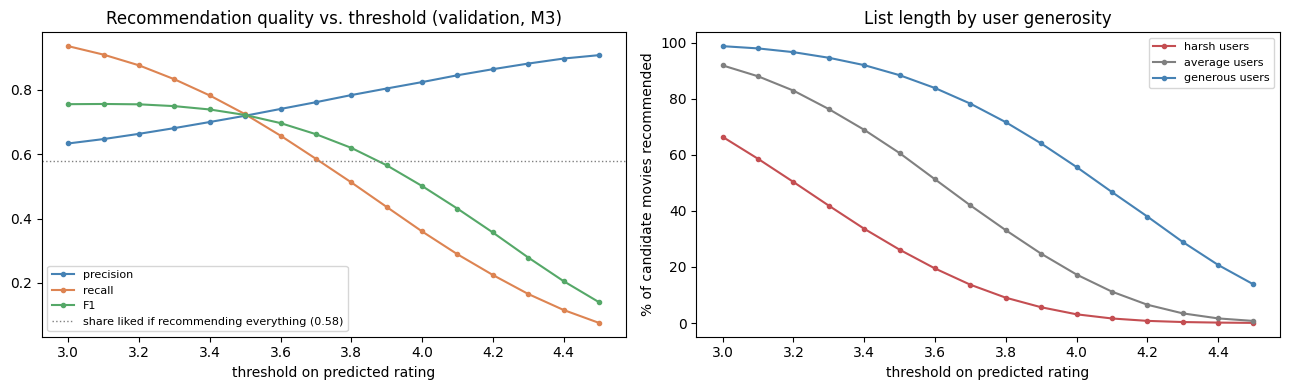

,precision,recall,% recommended,F1
threshold,,,,
3.0,0.633,0.935,85.682,0.755
3.1,0.647,0.909,81.511,0.756
3.2,0.663,0.876,76.608,0.755
3.3,0.681,0.832,70.930,0.749
3.4,0.700,0.782,64.838,0.739
3.5,0.719,0.724,58.388,0.721
3.6,0.740,0.657,51.510,0.696
3.7,0.761,0.585,44.618,0.662
3.8,0.783,0.512,37.927,0.619


In [8]:
p_val = pred["val"]["M3 + persona"]
liked = y["val"] >= 4
thresholds = np.round(np.arange(3.0, 4.51, 0.1), 2)
curve = []
for t in thresholds:
    rec = p_val >= t
    tp = (rec & liked).sum()
    curve.append({
        "threshold": t,
        "precision": tp / max(rec.sum(), 1),
        "recall": tp / liked.sum(),
        "% recommended": 100 * rec.mean(),
    })
curve = pd.DataFrame(curve).set_index("threshold")
curve["F1"] = 2 * curve["precision"] * curve["recall"] / (curve["precision"] + curve["recall"])

generosity = pd.qcut(X["val"]["user_mean"], 3, labels=["harsh", "average", "generous"])
by_group = pd.DataFrame({
    g: [100 * (p_val[generosity == g] >= t).mean() for t in thresholds] for g in ["harsh", "average", "generous"]
}, index=thresholds)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for col, color in [("precision", "steelblue"), ("recall", "#dd8452"), ("F1", "#55a868")]:
    axes[0].plot(curve.index, curve[col], marker="o", ms=3, label=col, color=color)
axes[0].axhline(liked.mean(), color="gray", ls=":", lw=1, label=f"share liked if recommending everything ({liked.mean():.2f})")
axes[0].set_xlabel("threshold on predicted rating")
axes[0].set_title("Recommendation quality vs. threshold (validation, M3)")
axes[0].legend(fontsize=8)
for g, color in zip(by_group.columns, ["#c44e52", "gray", "steelblue"]):
    axes[1].plot(by_group.index, by_group[g], marker="o", ms=3, label=f"{g} users", color=color)
axes[1].set_xlabel("threshold on predicted rating")
axes[1].set_ylabel("% of candidate movies recommended")
axes[1].set_title("List length by user generosity")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()
curve.round(3)

**Ranking view.** A recommended list is usually "the user's top *N*" rather than a fixed threshold. For users with ≥ 10 test movies, the movies are sorted by predicted rating and the top 10 are checked:
- **precision@10:** share of the top 10 that the user rated 4 or 5,
- **NDCG@10:** how close the order of the top 10 is to the ideal order (the user's own ratings sorted), 1 = perfect.

B0 / B1 predict the same value for all movies of a user and cannot rank, so the reference is a **random order** of the user's movies.

In [9]:
TOP_N = 10


def ranking_scores(scores, df, y_true):
    d = pd.DataFrame({"user": df["rater_id"].to_numpy(), "score": scores, "rating": y_true})
    d = d[d.groupby("user")["user"].transform("size") >= TOP_N]
    d["gain"] = 2.0 ** d["rating"] - 1
    top = d.sort_values(["user", "score"], ascending=[True, False]).groupby("user").head(TOP_N).copy()
    ideal = d.sort_values(["user", "rating"], ascending=[True, False]).groupby("user").head(TOP_N).copy()
    for t in (top, ideal):
        t["discount"] = 1 / np.log2(t.groupby("user").cumcount() + 2)
    dcg = (top["gain"] * top["discount"]).groupby(top["user"]).sum()
    idcg = (ideal["gain"] * ideal["discount"]).groupby(ideal["user"]).sum()
    return {
        "users": d["user"].nunique(),
        "precision@10": (top["rating"] >= 4).groupby(top["user"]).mean().mean(),
        "NDCG@10": (dcg / idcg).mean(),
    }


ranking = {"random order": ranking_scores(rng.random(len(y["test"])), parts["test"], y["test"])}
for name in FEATURES:
    ranking[name] = ranking_scores(pred["test"][name], parts["test"], y["test"])
pd.DataFrame(ranking).T.round(4)

,users,precision@10,NDCG@10
random order,5367.0,0.6183,0.6262
M1 content + user,5367.0,0.7025,0.7114
M2 + taste,5367.0,0.7186,0.7348
M3 + persona,5367.0,0.7195,0.7355


## 8. Feature importance, overall and per persona (RQ3)

**Permutation importance:** shuffle one group of features across rows (breaking its link to the rating) and measure how much the validation RMSE of M3 gets worse. Groups are shuffled together because related features (e.g. 18 genre columns) share information. Measured on up to 200,000 validation rows overall, and separately on the validation rows of each persona's users.

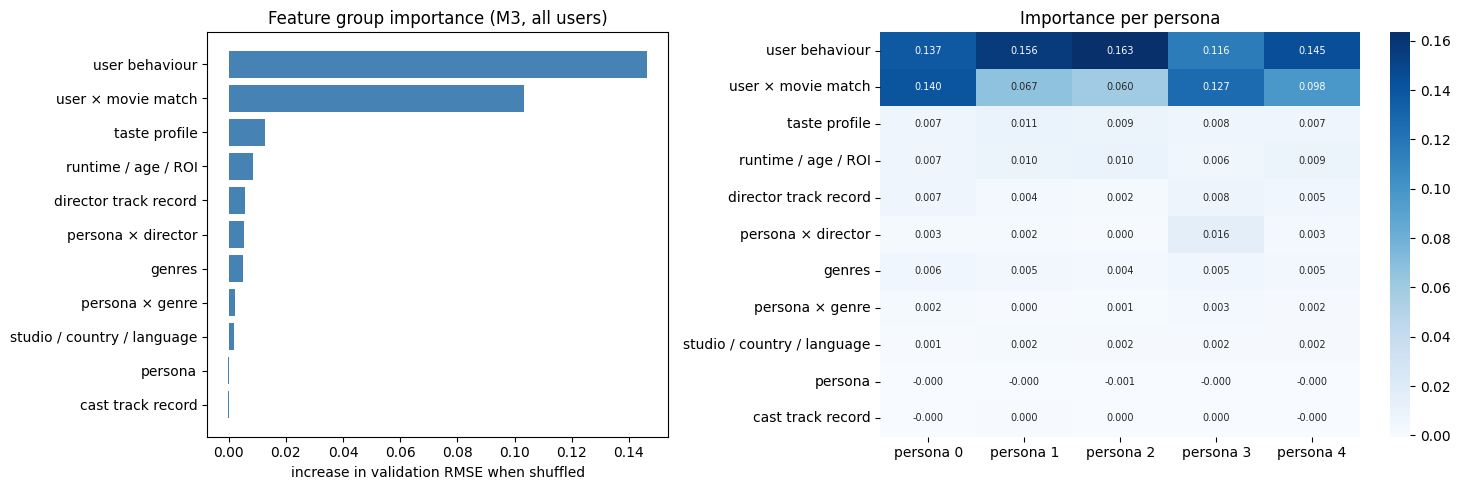

In [10]:
GROUPS = {
    "genres": GENRE_COLS,
    "runtime / age / ROI": MOVIE_NUMERIC,
    "studio / country / language": MOVIE_OTHER,
    "director track record": ["director_track_record"],
    "cast track record": ["cast_track_record"],
    "user behaviour": USER_COLS,
    "taste profile": TASTE_COLS,
    "user × movie match": MATCH_COLS,
    "persona": PERSONA_COLS,
    "persona × genre": ["persona_genre_score"],
    "persona × director": ["persona_director_score"],
}
m3, m3_cols = models["M3 + persona"], FEATURES["M3 + persona"]


def permutation_importance(Xp, yp, n_repeats=2):
    base = rmse(yp, predict(m3, Xp[m3_cols]))
    perm_rng = np.random.default_rng(RANDOM_STATE)
    out = {}
    for group, cols in GROUPS.items():
        increases = []
        for _ in range(n_repeats):
            Xs = Xp[m3_cols].copy()
            Xs[cols] = Xs[cols].to_numpy()[perm_rng.permutation(len(Xs))]
            increases.append(rmse(yp, predict(m3, Xs)) - base)
        out[group] = float(np.mean(increases))
    return pd.Series(out)


idx = rng.choice(len(y["val"]), size=min(200_000, len(y["val"])), replace=False)
overall = permutation_importance(X["val"].iloc[idx], y["val"][idx]).sort_values()

val_persona = personas["persona_id"].reindex(parts["val"]["rater_id"]).to_numpy()
per_persona = {}
for k in range(K):
    rows_k = np.flatnonzero(val_persona == k)
    rows_k = rng.choice(rows_k, size=min(50_000, len(rows_k)), replace=False)
    per_persona[f"persona {k}"] = permutation_importance(X["val"].iloc[rows_k], y["val"][rows_k])
per_persona = pd.DataFrame(per_persona).loc[overall.index[::-1]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [1, 1.3]})
axes[0].barh(overall.index, overall.values, color="steelblue")
axes[0].set_xlabel("increase in validation RMSE when shuffled")
axes[0].set_title("Feature group importance (M3, all users)")
sns.heatmap(per_persona, annot=True, fmt=".3f", cmap="Blues", ax=axes[1], annot_kws={"fontsize": 7})
axes[1].set_title("Importance per persona")
fig.tight_layout()
plt.show()

**Observations**

**RQ4 — from averages to personalization (test movies).**

| model | test RMSE | gain vs. user mean |
|---|---|---|
| B0 global mean | 1.065 | −6.8% |
| B1 user mean | 0.997 | 0 |
| M1 content + user | 0.974 | 2.3% |
| M2 + taste | 0.973 | 2.5% |
| M3 + persona | 0.965 | 3.3% |

- **Knowing the user matters most:** the user's own average already cuts the error of the global mean by ~7%.
- **Movie metadata adds a real but modest improvement** (M1 vs. B1: −0.023 RMSE, 95% interval over movies [−0.038, −0.007]). Predicting ratings of *unseen* movies from TMDB metadata alone is hard; most of what makes a film good is not in its budget, genre or cast.
- **Personalization:** on validation the taste profile gave most of the gain (M2) and the persona little; on test it is the reverse — M2 ≈ M1 (interval includes 0) while **M3 is reliably better than M2** (−0.008, interval [−0.015, −0.001]). With only ~200 movies per part the size of each step varies between the two sets, but both agree that the full personalized model M3 is the best, 3.3–3.5% below the user-mean baseline.
- The tree model beats the linear Ridge on the same features only slightly (0.965 vs. 0.966 on test): most of the signal is additive.

**RQ2 — polarization taste.** Neither the persona version built with `rating_std` nor the user's `taste_rating_std` changes the validation RMSE (0.952 vs. 0.952; 0.940 vs. 0.940). Taste for polarizing films describes personas (`08`) but does not help predict ratings of new films.

**Recommending ("add to list").** With M3 on validation movies, 58% of candidate movies are liked (≥ 4 stars):
- threshold 3.5 recommends 58% of movies with precision 0.72 and recall 0.72 (near the best F1);
- threshold 4.0 recommends 25% with precision 0.82 but recall 0.36;
- each +0.1 on the threshold buys ~2 points of precision for ~5–7 points of recall.
- A single threshold treats user types very differently: at 4.0 harsh users get ~3% of movies recommended and generous users ~56%. A **per-user top-N list** avoids this: the top 10 predicted movies of a user contain 72% liked films (NDCG@10 0.74) vs. 62% (0.63) for a random order of the same movies.

**RQ3 — what drives the predictions.**
- **User behaviour** (mean, std, share of 4–5 stars) is by far the most important group, followed by the **user × movie match** features (the user's taste applied to this movie's genres and production features). Movie-only features (runtime / age / ROI, director track record, genres) matter much less, and the cast track record adds nothing once the other features are present.
- The **persona one-hot** itself has ~0 importance: the persona's information reaches the model through the persona × movie scores.
- **Differences between personas:** the user × movie match matters most for *Classic epics* (0: 0.140) and *Arthouse & international* (3: 0.127) and least for *Family & adventure* (1) and *Light & divisive* (2) — the more specific a persona's taste, the more a movie's fit to it matters. The **director** matters most for *Arthouse & international*: `persona_director_score` is 0.016 for persona 3 vs. ≤ 0.003 for all others, and the director track record is highest for personas 3 and 0 (0.008 / 0.007) vs. 0.002 for *Light & divisive*. So yes — director track record matters more for some personas than others.

**Limits.** Trained on a sample of 8,000 users (memory); validation and test each hold ~200 movies, so single-step differences are noisy (hence the bootstrap intervals); the models only see films users chose to rate, not random films.